# Packages & Global Info

In [18]:
# Packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
# Aggregation levels
levels = {'1 min': 1/60, '10 min': 1/6, '30 min': 0.5, '1 h': 1,
              '2 h': 2, '3 h': 3, '4 h': 4, '6 h': 6, '8 h': 8, '12 h': 12, '24 h': 24}

# ARI

In [20]:
# ARI results
ARI_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/03_working_notebooks/results/ARI.csv", index_col=0)

ARI = {}
for col in ARI_df.columns:
    ARI[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in ARI_df[col].items()
    }

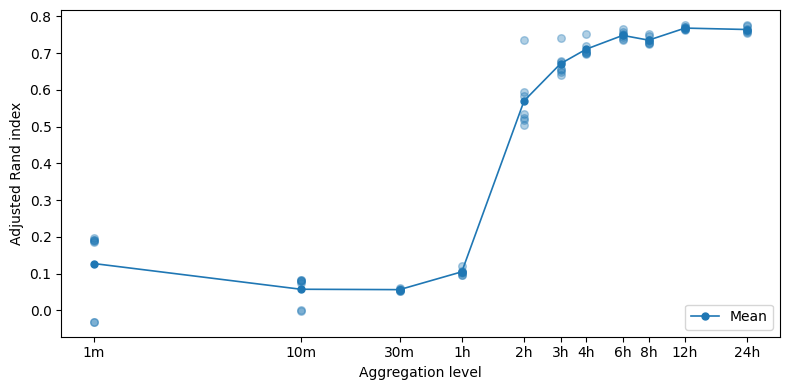

In [21]:
# Plot of ARIs & mean for each aggregtion level
fig, ax = plt.subplots(figsize=(8, 4))

agg_levels = np.array([h for _, h in levels.items() ])
adj_rand = [np.array(list(ARI[name].values())) for name in levels]

ari_means = np.array([ari.mean() for ari in adj_rand])

for x, aris in zip(agg_levels, adj_rand):
    ax.scatter(x * np.ones(len(aris)), aris, color='tab:blue', alpha=0.35, s=30, zorder=2)

ax.plot(agg_levels, ari_means , marker='o', ms=5, lw=1.2, zorder=3, label='Mean')

ax.set_xscale('log')
ax.set_xticks(agg_levels)
ax.set_xticklabels(['1m','10m','30m','1h','2h','3h','4h','6h','8h','12h','24h'])
ax.minorticks_off()
ax.set_xlabel('Aggregation level')
ax.set_ylabel('Adjusted Rand index')
ax.legend(loc='lower right')
plt.tight_layout()

# VI

In [5]:
# VI results 
VI_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/03_working_notebooks/results/VI.csv", index_col=0)

VI = {}
for col in VI_df.columns:
    VI[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in VI_df[col].items()
    }

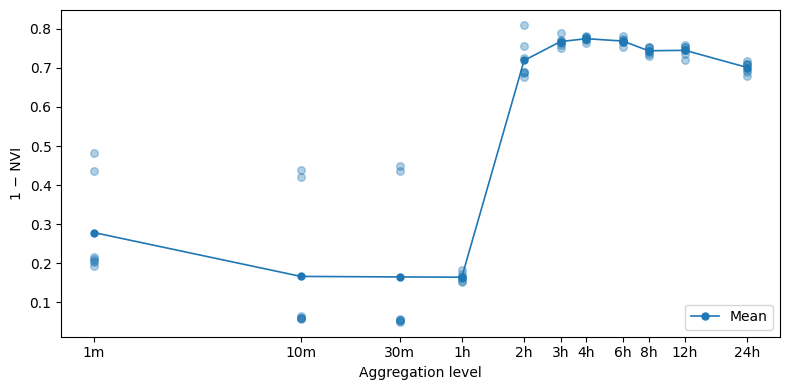

In [6]:
one_minus_VI = {name: {pair: 1 - v for pair, v in d.items()} for name, d in VI.items()}

fig, ax = plt.subplots(figsize=(8, 4))

agg_levels = np.array([h for _, h in levels.items()])
sim = [np.array(list(one_minus_VI[name].values())) for name in levels]
inverse_vi_means = np.array([s.mean() for s in sim])

for x, s in zip(agg_levels, sim):
    ax.scatter(x * np.ones(len(s)), s, color='tab:blue', alpha=0.35, s=30, zorder=2)

ax.plot(agg_levels, inverse_vi_means, marker='o', ms=5, lw=1.2, zorder=3, label='Mean')

ax.set_xscale('log')
ax.set_xticks(agg_levels)
ax.set_xticklabels(['1m','10m','30m','1h','2h','3h','4h','6h','8h','12h','24h'])
ax.minorticks_off()
ax.set_xlabel('Aggregation level')
ax.set_ylabel('1 − NVI')
ax.legend(loc='lower right')
plt.tight_layout()

# PSI

In [7]:
# ARI results
PSI_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/03_working_notebooks/results/PSI.csv", index_col=0)

PSI = {}
for col in PSI_df.columns:
    PSI[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in PSI_df[col].items()
    }

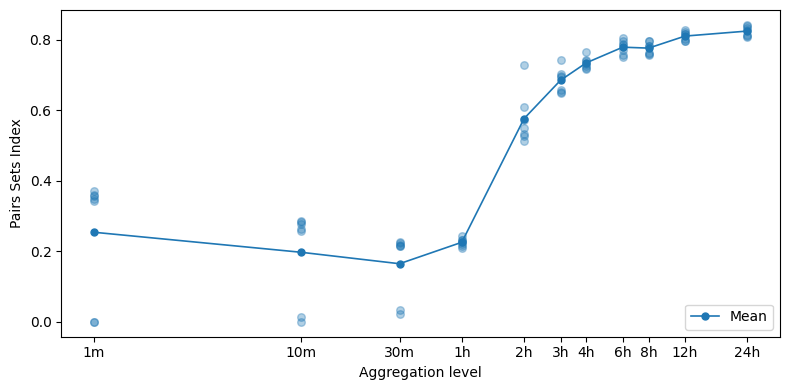

In [8]:
# Plot of PSIs & mean for each aggregtion level
fig, ax = plt.subplots(figsize=(8, 4))

agg_levels = np.array([h for _, h in levels.items() ])
psi_vals = [np.array(list(PSI[name].values())) for name in levels]

psi_means = np.array([psi.mean() for psi in psi_vals])

for x, aris in zip(agg_levels, psi_vals):
    ax.scatter(x * np.ones(len(aris)), aris, color='tab:blue', alpha=0.35, s=30, zorder=2)

ax.plot(agg_levels, psi_means , marker='o', ms=5, lw=1.2, zorder=3, label='Mean')

ax.set_xscale('log')
ax.set_xticks(agg_levels)
ax.set_xticklabels(['1m','10m','30m','1h','2h','3h','4h','6h','8h','12h','24h'])
ax.minorticks_off()
ax.set_xlabel('Aggregation level')
ax.set_ylabel('Pairs Sets Index')
ax.legend(loc='lower right')
plt.tight_layout()

# Combined

In [22]:
# Standardise measures
ari_standardised = (ari_means - np.mean(ari_means))/np.std(ari_means)
inv_vi_standardised = (inverse_vi_means - np.mean(inverse_vi_means))/np.std(inverse_vi_means)
psi_standardised = (psi_means - np.mean(psi_means))/np.std(psi_means)

# Combined measure
combined = (ari_standardised + inv_vi_standardised + psi_standardised)/3

# Scale the combined measure
combined_scaled = (combined - combined.min())/(combined.max() - combined.min())

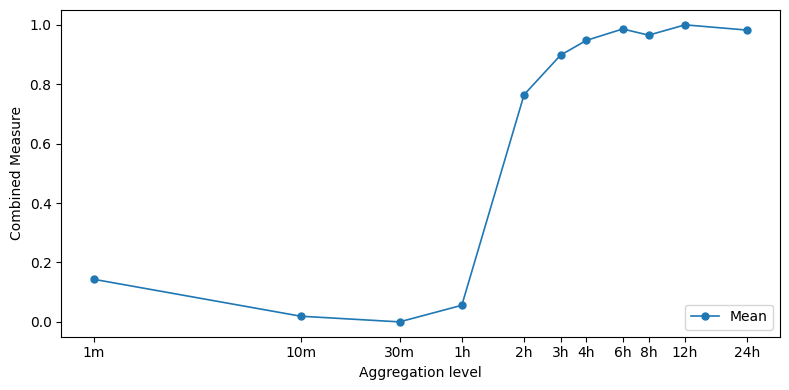

In [23]:
# Plot combined measure
fig, ax = plt.subplots(figsize = (8,4))

agg_levels = np.array([h for _, h in levels.items() ])

ax.plot(agg_levels, combined_scaled , marker='o', ms=5, lw=1.2, zorder=3, label='Mean')

ax.set_xscale('log')
ax.set_xticks(agg_levels)
ax.set_xticklabels(['1m','10m','30m','1h','2h','3h','4h','6h','8h','12h','24h'])
ax.minorticks_off()
ax.set_xlabel('Aggregation level')
ax.set_ylabel('Combined Measure')
ax.legend(loc='lower right')
plt.tight_layout()

In [24]:
# Distribution of stability values for each measure 
ari_dist = np.concatenate([np.array(list(ARI[name].values())) for name in levels])
vi_dist  = np.concatenate([np.array(list(one_minus_VI[name].values())) for name in levels])
psi_dist = np.concatenate([np.array(list(PSI[name].values())) for name in levels])

# Mean and standard deviation of measures
ari_mean, ari_std = ari_dist.mean(), ari_dist.std()
vi_mean,  vi_std  = vi_dist.mean(),  vi_dist.std()
psi_mean, psi_std = psi_dist.mean(), psi_dist.std()

In [25]:
# Combined measure
combined_measure = {} 

for agg_level in levels:
    pairs = list(ARI[agg_level].keys())  
    z_ari = (np.array([ARI[agg_level][p] for p in pairs]) - ari_mean) / ari_std
    z_vi  = (np.array([one_minus_VI[agg_level][p] for p in pairs]) - vi_mean) / vi_std
    z_psi = (np.array([PSI[agg_level][p] for p in pairs]) - psi_mean) / psi_std

    combined_measure[agg_level] = (z_ari + z_vi + z_psi) / 3

In [26]:
all_combined = np.concatenate([combined_measure[agg_level] for agg_level in levels])
c_min, c_max = all_combined.min(), all_combined.max()

In [27]:
combined_scaled = {
    agg_level: (combined_measure[agg_level] - c_min) / (c_max - c_min)
    for agg_level in levels
}

In [28]:
combined_means = np.array([combined_scaled[agg_level].mean() for agg_level in levels])

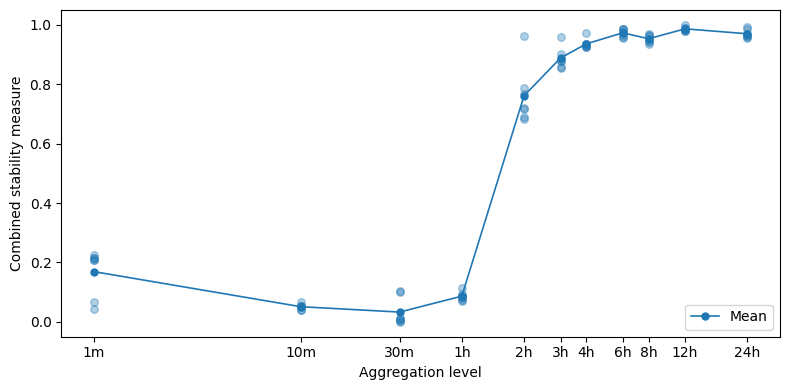

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))

for x, name in zip(agg_levels, levels):
    vals = combined_scaled[name]
    ax.scatter(x * np.ones(len(vals)), vals, color='tab:blue', alpha=0.35, s=30, zorder=2)

ax.plot(agg_levels, combined_means , marker='o', ms=5, lw=1.2, zorder=3, label='Mean')

ax.set_xscale('log')
ax.set_xticks(agg_levels)
ax.set_xticklabels(['1m','10m','30m','1h','2h','3h','4h','6h','8h','12h','24h'])
ax.minorticks_off()
ax.set_xlabel('Aggregation level')
ax.set_ylabel('Combined stability measure')
ax.legend(loc='lower right')
plt.tight_layout()

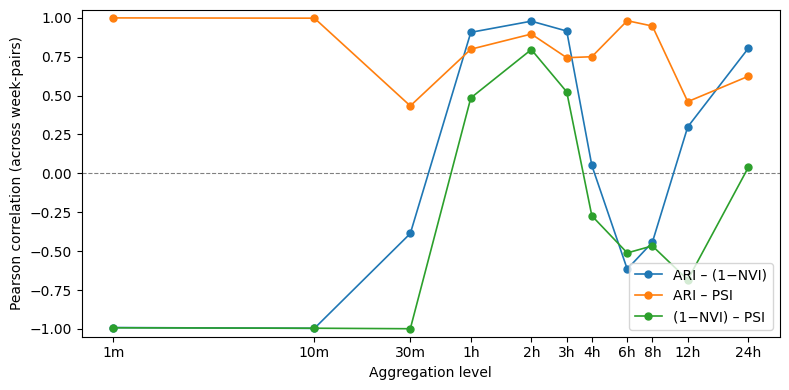

In [58]:
# %%
# Pairwise correlations between metrics at each aggregation level
corr_ari_vi  = []
corr_ari_psi = []
corr_vi_psi  = []

for agg_level in levels:
    pairs = list(ARI[agg_level].keys())
    z_ari = (np.array([ARI[agg_level][p] for p in pairs]) - ari_mean) / ari_std
    z_vi  = (np.array([one_minus_VI[agg_level][p] for p in pairs]) - vi_mean) / vi_std
    z_psi = (np.array([PSI[agg_level][p] for p in pairs]) - psi_mean) / psi_std

    corr_ari_vi.append(np.corrcoef(z_ari, z_vi)[0, 1])
    corr_ari_psi.append(np.corrcoef(z_ari, z_psi)[0, 1])
    corr_vi_psi.append(np.corrcoef(z_vi, z_psi)[0, 1])

corr_ari_vi  = np.array(corr_ari_vi)
corr_ari_psi = np.array(corr_ari_psi)
corr_vi_psi  = np.array(corr_vi_psi)

# %%
fig, ax = plt.subplots(figsize=(8, 4))

ax.axhline(0, color='grey', lw=0.8, ls='--', zorder=1)

ax.plot(agg_levels, corr_ari_vi,  marker='o', ms=5, lw=1.2, label='ARI – (1−NVI)')
ax.plot(agg_levels, corr_ari_psi, marker='o', ms=5, lw=1.2, label='ARI – PSI')
ax.plot(agg_levels, corr_vi_psi,  marker='o', ms=5, lw=1.2, label='(1−NVI) – PSI')

ax.set_xscale('log')
ax.set_xticks(agg_levels)
ax.set_xticklabels(['1m','10m','30m','1h','2h','3h','4h','6h','8h','12h','24h'])
ax.minorticks_off()
ax.set_xlabel('Aggregation level')
ax.set_ylabel('Pearson correlation (across week-pairs)')
ax.set_ylim(-1.05, 1.05)
ax.legend(loc='lower right')
plt.tight_layout()